In [1]:
import os
import pandas as pd
from data.metrics import Evaluator
from data.small_context import get_datasets
from sklearn.metrics import mean_absolute_error
from loguru import logger
import numpy as np
from matplotlib import pyplot as plt
import torch
from models.chronos_forecast import get_predictions_chronos
plt.style.use('tableau-colorblind10')

output_path = './outputs/test/'
filelist = os.listdir(output_path)
filelist

/home/amir/miniconda3/envs/llmtime/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['AusBeerDataset.pkl', 'AirPassengersDataset.pkl']

# Darts

In [2]:
computed_datasets = list(get_datasets().keys())
computed_datasets = [d for d in computed_datasets if d+".pkl" in filelist]
computed_datasets

['AirPassengersDataset', 'AusBeerDataset']

In [3]:
chronos_out = {}
for dsname,data in get_datasets().items():
    if dsname not in computed_datasets:
        continue
    train, test = data

    quantiles, median = get_predictions_chronos(
        input_tensor=torch.tensor(train.values),
        prediction_length=len(test),
        quantiles=[0.1, 0.5, 0.9]
    )
    chronos_out[dsname] = {'median': pd.Series(median.cpu().numpy().squeeze(), index=test.index, name="Y")}

In [4]:
chronos_out['AirPassengersDataset']['median']

Month
1958-08-01    477.269867
1958-09-01    430.373901
1958-10-01    358.608856
1958-11-01    342.976868
1958-12-01    363.582672
1959-01-01    374.951385
1959-02-01    388.451721
1959-03-01    411.899719
1959-04-01    419.715698
1959-05-01    428.952820
1959-06-01    471.585510
1959-07-01    515.639282
1959-08-01    512.797119
1959-09-01    474.427673
1959-10-01    404.794250
1959-11-01    382.767395
1959-12-01    394.136108
1960-01-01    405.504822
1960-02-01    419.005188
1960-03-01    433.216064
1960-04-01    436.058258
1960-05-01    443.163696
1960-06-01    497.165100
1960-07-01    542.640015
1960-08-01    535.534546
1960-09-01    494.322937
1960-10-01    426.110626
1960-11-01    409.768066
1960-12-01    427.531708
Freq: MS, Name: Y, dtype: float32

In [5]:
score_rag = []
score_norag = []
score_chronos = []
for dataset_name in computed_datasets:
    gt = get_datasets()[dataset_name]
    output_rag = pd.read_pickle(f'{output_path}/{dataset_name}.pkl')
    output_norag = pd.read_pickle(f'./precomputed_outputs/darts/gpt4/{dataset_name}.pkl')
    mae_rag = mean_absolute_error(gt[1], output_rag['gemma-12b']['median'])
    mae_norag = mean_absolute_error(gt[1], output_norag['gpt-4']['median'])
    mae_chronos = mean_absolute_error(gt[1], chronos_out[dataset_name]['median'])
    score_rag.append((dataset_name, mae_rag))
    score_norag.append((dataset_name, mae_norag))
    score_chronos.append((dataset_name, mae_chronos))


In [16]:
# # extract datasets and values
# datasets = [x[0] for x in score_rag]
# rag_values = np.array([x[1] for x in score_rag])
# gpt_values = np.array([x[1] for x in score_gpt])

# # scale per dataset by max value of that dataset
# scaled_rag = rag_values / np.maximum(rag_values, gpt_values)
# scaled_gpt = gpt_values / np.maximum(rag_values, gpt_values)

# # close the loop for radar plot
# scaled_rag = np.append(scaled_rag, scaled_rag[0])
# scaled_gpt = np.append(scaled_gpt, scaled_gpt[0])
# angles = np.linspace(0, 2 * np.pi, len(datasets), endpoint=False).tolist()
# angles += angles[:1]

# # plot
# fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
# ax.plot(angles, scaled_rag, 'o-', linewidth=2, label='RAG')
# ax.fill(angles, scaled_rag, alpha=0.25)
# ax.plot(angles, scaled_gpt, 'o-', linewidth=2, label='GPT-4')
# ax.fill(angles, scaled_gpt, alpha=0.25)

# ax.set_thetagrids(np.degrees(angles[:-1]), datasets)  # increase labelpad

# ax.set_ylim(0, 1)
# ax.set_title("MAE Comparison (scaled per dataset, relative)")
# ax.legend(loc='upper right')

# plt.show()

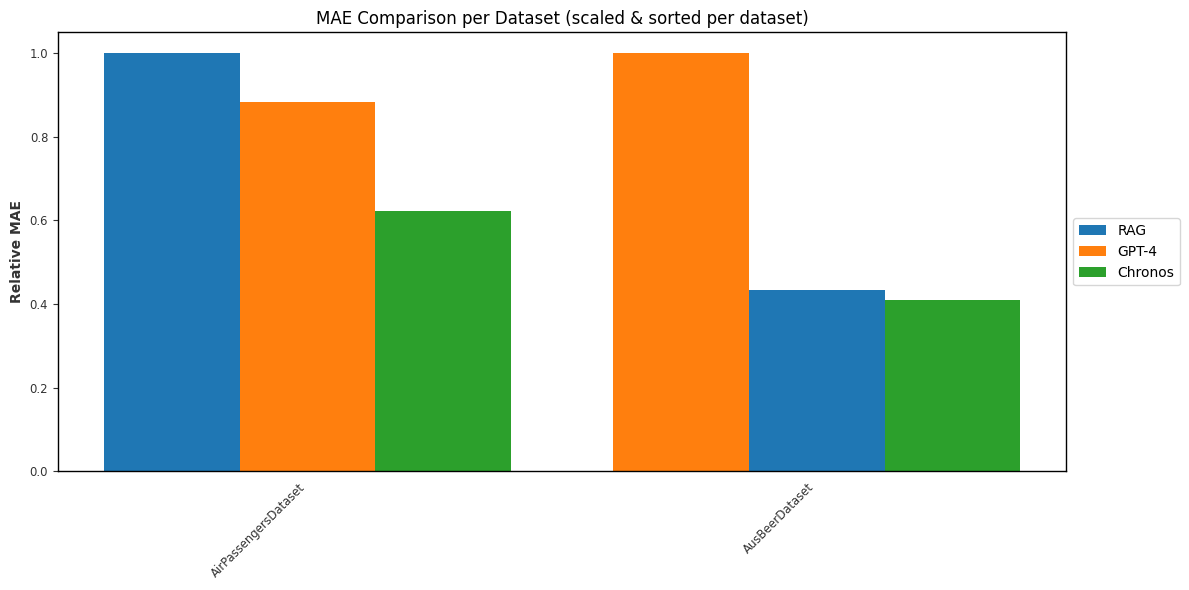

In [18]:
import numpy as np
import matplotlib.pyplot as plt

scores = {
    "RAG": score_rag,
    "GPT-4": score_norag,
    "Chronos": score_chronos,
}

# ---- Build arrays ----
datasets = [x[0] for x in next(iter(scores.values()))]  # dataset names
model_names = list(scores.keys())

# Values: rows=models, cols=datasets
values = np.array([[x[1] for x in scores[m]] for m in model_names])

# Scale per dataset by max value
max_per_dataset = values.max(axis=0)
scaled_values = values / max_per_dataset

# Assign fixed colors to models
cmap = plt.get_cmap("tab10")
colors = {model: cmap(i) for i, model in enumerate(model_names)}

x = np.arange(len(datasets))
width = 0.8  # total width per dataset
bar_width = width / len(model_names)

fig, ax = plt.subplots(figsize=(12, 6))

for j, ds in enumerate(datasets):
    vals = scaled_values[:, j]
    models_sorted = np.argsort(-vals)  # sort descending
    
    for i, idx in enumerate(models_sorted):
        model = model_names[idx]
        ax.bar(
            j - width/2 + (i + 0.5) * bar_width,
            vals[idx],
            bar_width,
            color=colors[model],
            label=model if j == 0 else ""  # legend once
        )

ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha='right')
ax.set_ylabel('Relative MAE')
ax.set_title('MAE Comparison per Dataset (scaled & sorted per dataset)')

for spine in ax.spines.values():
    spine.set_visible(True)

# Legend outside
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True)

ax.grid(False)
plt.tight_layout()
plt.show()


In [18]:
logger.info(f"RAG MAE: {score_rag}")
logger.info(f"GPT-4 MAE: {score_norag}")
logger.info(f"Chronos MAE: {score_chronos}")

2025-10-01 16:04:54.351 | INFO     | __main__:<module>:1 - RAG MAE: [('AirPassengersDataset', 39.07340689655173), ('AusBeerDataset', 11.991172093023236)]
2025-10-01 16:04:54.354 | INFO     | __main__:<module>:2 - GPT-4 MAE: [('AirPassengersDataset', 34.549255172413815), ('AusBeerDataset', 27.68199999999997)]
2025-10-01 16:04:54.357 | INFO     | __main__:<module>:3 - Chronos MAE: [('AirPassengersDataset', 24.352636929216057), ('AusBeerDataset', 11.324950462163882)]
